# Player Statistics

This notebook trains and serialises a machine learning model to predict the basketball position of a player based on their in-game counting statistics (e.g. points, rebounds, assists etc). The approach taken includes:
* Splitting the data into train/test sets with stratification
* Using cross-validation (CV=4) to get a reliable estimate of model generalisation during model selection
* Keeping the test set completely held out during model selection and hyperparameter tuning
* Comparing multiple models (Logistic Regression, Decision Trees, Random Forest, Histogram Gradient Boosting, SVM) using nested cross-validation
* Using appropriate metrics (balanced_accuracy and f1_macro) for the imbalanced multi-class problem
* Evaluating the final chosen model on the held-out test set to get an unbiased estimate of performance
* Retraining the best model on the entire dataset (train + test). 

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import warnings
from IPython.utils import io
from contextlib import contextmanager
from scipy.stats import uniform, loguniform
import optuna
import xgboost as xgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import balanced_accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif, chi2
from sklearn.svm import  SVC
from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_validate, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

sns.set_theme()
%matplotlib inline

/Users/danielliu/miniconda3/envs/positionn/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
np.random.seed(0)

## (1) Read in Data


In [3]:
player_statistics = pd.read_csv(os.path.join("data", "api_player_stats.csv"))

## (2) Problem definition

In [4]:
player_statistics['pos'].value_counts()

pos
G    1781
F    1476
C     559
Name: count, dtype: int64

Since most observations are Forward and Guards, this represents an **imbalanced, multi-classs classification problem.** Additionally, False Positive's and False Negative's are equally importance (i.e. we want fair performance predicting across all classes).

As such, we will use appropriate metrics like:

* `balanced_accuracy`,
* `f1_macro`

## (3) Feature Selection

### Preparation of dataset

In [5]:
# separate data
target_name = "pos"
target = player_statistics[target_name]
data = player_statistics.drop(columns=[target_name, "player", "player_id"])

# retrieve column types
numerical_columns_selector = selector(dtype_exclude=object)
numerical_columns = numerical_columns_selector(data)

# define transformers
numerical_preprocessor = StandardScaler()

# define column transformer
preprocessor = ColumnTransformer(
    [
        ("numerical_preprocessing", numerical_preprocessor, numerical_columns)
    ],
    remainder="passthrough"
)

In [6]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size = 0.25, stratify=target, random_state=42)

# Obtain feature names
feats = data.columns.tolist()

In [7]:
# KBest
def select_kbest_rankings(X_train, y_train, feats):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)
    select = SelectKBest(k=11)
    select.fit_transform(X_scaled, y_train)
    scores = [(i, score) for i, score in enumerate(select.scores_)]
    sorted_scores = sorted(scores, key=lambda tup: tup[1], reverse=True)
    sorted_scores_feats = [(feats[idx], score) for idx, score in sorted_scores]
    sorted_feats = [feats[i] for i, _ in sorted_scores]
    print("--------------------------------")
    print("KBest Feature Selection")
    print("--------------------------------")
    print("Features with scores:")
    print(sorted_scores_feats, '\n')
    print("Features in order of importance (descending):")
    print(sorted_feats)
    print("--------------------------------")

# Mutual Information Gain
def mutualinfo_rankings(X_train, y_train, feats):
    importances = mutual_info_classif(X_train, y_train)
    df_test = pd.DataFrame({"features": feats, "importances": importances})
    df_sorted = df_test.sort_values('importances', ascending= False)
    print("Mutual Information Gain Feature Selection")
    print("--------------------------------")
    print("Features with scores:")
    print(list(zip(df_sorted.features.to_list(), df_sorted.importances.to_list())), '\n')
    print("Features in order of importance (descending):")
    print(df_sorted.features.to_list())
    print("--------------------------------")

def chi2_rankings(X_train, y_train, feats):
    # Drop 4 negative records
    mask = (X_train >= 0).all(axis=1)
    X_train_clean = X_train[mask]
    y_train_clean = y_train[mask]
    # Run chi2 test
    select = SelectKBest(score_func=chi2, k='all')
    select.fit(X_train_clean, y_train_clean)
    scores = [(feats[i], score) for i, score in enumerate(select.scores_)]
    sorted_scores = sorted(scores, key=lambda x: x[1], reverse=True)
    print("Chi2 Feature Selection")
    print("--------------------------------")
    print("Features with scores:")
    print(sorted_scores, '\n')
    print("Features in order of importance (descending):")
    print([f for f, _ in sorted_scores])
    print("--------------------------------")

select_kbest_rankings(X_train, y_train, feats)
mutualinfo_rankings(X_train, y_train, feats)
chi2_rankings(X_train, y_train, feats)

--------------------------------
KBest Feature Selection
--------------------------------
Features with scores:
[('BLK', 560.9086296513454), ('REB', 465.4651890363058), ('AST_TO', 257.69150182073435), ('AST', 167.57672031096845), ('STL', 76.21534049660785), ('STOCKS', 74.7085190399088), ('TOV', 22.307756539974154), ('PTS', 6.522924962199562), ('FIC', 5.9788655559022335), ('year', 1.7228001245782645), ('age', 1.1132622841593616)] 

Features in order of importance (descending):
['BLK', 'REB', 'AST_TO', 'AST', 'STL', 'STOCKS', 'TOV', 'PTS', 'FIC', 'year', 'age']
--------------------------------
Mutual Information Gain Feature Selection
--------------------------------
Features with scores:
[('BLK', 0.1602179759847202), ('AST_TO', 0.13668106302099314), ('REB', 0.12955474436044678), ('AST', 0.08996683642482672), ('TOV', 0.038483873154285586), ('STOCKS', 0.03644539478898601), ('STL', 0.03615917687088688), ('FIC', 0.01315301622332421), ('PTS', 0.00792531804166563), ('year', 0.0051684255456261

Get rid of age and year attributes (consistently part the 3 least important attributes).

In [8]:
# separate data
target_name = "pos"
target_response = player_statistics[target_name]

# encode target response
le = LabelEncoder()
target = le.fit_transform(target_response)

# separate data
data = player_statistics.drop(columns=[target_name, "player", "age", "year", "player_id"])

# retrieve column types
numerical_columns_selector = selector(dtype_exclude=object)
numerical_columns = numerical_columns_selector(data)

# define transformers
numerical_preprocessor = StandardScaler()

# define column transformer
preprocessor = ColumnTransformer(
    [
        ("numerical_preprocessing", numerical_preprocessor, numerical_columns)
    ],
    remainder="passthrough"
)

## (4) Building ML Model

### Defining PlayerStatisticsModel class

In [9]:
class PlayerStatisticsModel:
    """
     This class enables easy the creation and evaluation of different models to predict a players position based
     on their statistics.
    """
    def __init__(self, model, preprocessor: ColumnTransformer, data: pd.DataFrame, target: pd.Series, cv: int):
        """
         Initialisation of PlayerStatisticsModel class.
        
         Inputs:
          - model: sklearn machine learning model class
          - preprocessor (ColumnTransformer): preprocessing steps
          - data: input features
          - target: input target
          - cv: number of cv folds to estimate generalisability of model
        """
        self.metrics = ["balanced_accuracy", "f1_macro"]  # metrics to evaluate/fit models
        self.cv = cv  # number of cv folds
        self.results = pd.DataFrame()   # dataframe to store performance results of models
        self.data = data
        self.target = target
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(data, target, test_size = 0.25, stratify=target, random_state=42)
        self.preprocessor = preprocessor
        self.model = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("model", model)
            ]
        )
    @contextmanager
    def _suppress_warnings_and_output(self):
        # save original warning environment variable
        original_warnings = os.environ.get("PYTHONWARNINGS", "")
        
        # suppress UserWarning and FutureWarning
        os.environ["PYTHONWARNINGS"] = "ignore::UserWarning, ignore::FutureWarning"
        warnings.filterwarnings("ignore", category=UserWarning)
        warnings.filterwarnings("ignore", category=FutureWarning)

        # capture all stdout/stderr output
        with io.capture_output() as captured:
            try:
                yield captured
            finally:
                # restore warnings environment and filters
                os.environ["PYTHONWARNINGS"] = original_warnings
                warnings.filterwarnings("default", category=UserWarning)
                warnings.filterwarnings("default", category=FutureWarning)
    def print_cv_results(self, dict_results:dict[tuple]):
        """
         Prints the mean and standard deviation cross-validation score for a specified metrics in a pretty format.
        
         Inputs:
          - dict_results (dict[tuple]): the mean & std results of a model on all evaluation metrics
        """
        for metric, value in dict_results.items():
            print(f"The mean cross-validation {metric} score is: "
            f"{value[0]:.3f} ± {value[1]:.3f}")
    def plot_fold_comparison(self, metric: str, fold_results: tuple[list[int]], label_names: tuple[str], colors: tuple[str]):
        """
         Plots a comparison of the model's evaluation metric (i.e. performance) on each individual cross-validation
         fold. If there are 4 cross-validation folds, a scatterplot with four dots will be plotted.
        
         Inputs:
          - metric (str): sklearn evaluation metric of choice
          - fold_results (tuple[list[int]]): tuple containing the fold results of each model
          - label_names (tuple[str]): names to give each to each model in the legend of plot
          - colors (tuple[str]): colors to give each model in the plot
        """
        # handle edge case: user passes in invalid metric to plot
        if metric not in self.metrics:
            raise Exception(f"Please pass in a valid metric: {self.metrics}")
        else:
            fig, ax = plt.subplots(figsize=(6, 5))
            # iterate through each model's fold_result, adding scatterplots
            for i in range(len(fold_results)):
                indicies = np.arange(len(fold_results[i][metric]))
                sns.scatterplot(x=indicies, y=fold_results[i][metric], color=f"tab:{colors[i]}", label=label_names[i], ax=ax)
            # plot axis settings
            ax.set_xlabel("Cross-validation iteration")
            ax.set_ylabel("Balanced Accuracy")
            ax.set_title(f"{self.cv}-Fold {metric}")
            ax.set_xticks(np.arange(0, self.cv))
            ax.set_ylim(0,1)
            ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    def _add_model_results(self, model_result: dict[list], model_name: str):
        """
         Anonymous function that concatenates the mean and standard deviation cross-validation score for all
         specified metrics of a model onto a pre-existing dataframe (self.results). This enables us to 
         quickly compare the cv-performance of models as we build them.

         Inputs:
          - model_result (dict[list]): dictionary containing the mean & std results for each model metric
          - model_name (str): name of the model that will exist as its index in the self.results df
        """   
        # Gets model results as df to append to self.results
        df = pd.DataFrame(model_result)
        # extract rows and add suffixes to column names, then combine
        mean_row = df.iloc[0].rename(lambda col: f"{col}_mean")
        std_row = df.iloc[1].rename(lambda col: f"{col}_std")
        flattened_series = pd.concat([mean_row, std_row])
        flattened_df = pd.DataFrame([flattened_series])
        # set the index to the model name
        flattened_df.index = [model_name]
        # if model already exists in results df, then replace. Otherwise, append.
        if model_name in list(self.results.index):
            self.results.loc[model_name] = flattened_df.iloc[0]
        else:
            self.results = pd.concat([self.results, flattened_df])
    def cv_score(self, model_name: str) -> tuple[dict[list], dict[list]]:
        """
         Runs cross-validation on the default model (i.e. without hyperparameter tuning), obtaining the 
         performance of the model.

         Inputs:
          - model_name (str): name of the model that will exist as its index in the self.results df
         
         Returns:
          - dict_scores_agg (dict[list]): dictionary containing the mean & std results for each model metric
          - dict_scores_folds (dict[list]): dictionary containing the model metric results for each fold
        """   
        # get CV scores for default model
        dict_scores_agg = dict()
        dict_scores_folds = dict()
        for metric in self.metrics:
            cv_results = cross_validate(self.model, data, target, cv=self.cv, scoring=metric)
            scoring = cv_results['test_score']
            dict_scores_agg[metric] = (scoring.mean(), scoring.std())
            dict_scores_folds[metric] = scoring
        self._add_model_results(dict_scores_agg, model_name)
        return dict_scores_agg, dict_scores_folds
    def grid_search_cv_score(self, model_name: str, param_grid: dict):
        """
         Fits a model with grid_search to tune its hyperparameters. Then performs nested cross-validation to
         obtain an estimate of the generalisability of the model & variance of this estimate.

         Inputs:
          - model_name (str): name of the model that will exist as its index in the self.results df
          - param_grid (dict): grid of hyperparameters to iterate through
         
         Returns:
          - dict_scores_agg (dict[list]): dictionary containing the mean & std results for each model metric
          - dict_scores_folds (dict[list]): dictionary containing the model metric results for each fold
          - best_model: sklearn model of best performing model after gridsearch hyperparameter tuning
        """
        with self._suppress_warnings_and_output():
            model_grid_search = GridSearchCV(self.model, param_grid=param_grid, n_jobs=-1, scoring=self.metrics, refit=self.metrics[0], verbose=1)
            # fit grid search on training data to extract best model
            model_grid_search.fit(self.X_train, self.y_train)
            best_model = model_grid_search.best_estimator_
            # get nested CV scores for best model
            dict_scores_agg = dict()
            dict_scores_folds = dict()
            # perform nested cv for each metric, storing results in dictionaries
            for metric in self.metrics:
                cv_results = cross_validate(model_grid_search, data, target, cv=self.cv, n_jobs=-1, scoring=metric)
                scoring = cv_results['test_score']
                dict_scores_agg[metric] = (scoring.mean(), scoring.std())
                dict_scores_folds[metric] = scoring
            # add results to dataframe for easy model comparison
            self._add_model_results(dict_scores_agg, model_name)
            return dict_scores_agg, dict_scores_folds, best_model
    def randomised_search_cv_score(self, model_name: str, param_distributions: dict, n_iter: int):
        """
         Fits a model with randomised_search to tune its hyperparameters. Then performs nested cross-validation to
         obtain an estimate of the generalisability of the model & variance of this estimate.

         Inputs:
          - model_name (str): name of the model that will exist as its index in the self.results df
          - param_distributions (dict): range of possible values each hyperparameter that can be sampled
          - n_iter (int): number of iterations to run randomised_search (i.e. models to be fitted & evaluated)
         
         Returns:
          - dict_scores_agg (dict[list]): dictionary containing the mean & std results for each model metric
          - dict_scores_folds (dict[list]): dictionary containing the model metric results for each fold
          - best_model: sklearn model of best performing model after gridsearch hyperparameter tuning
        """
        with self._suppress_warnings_and_output():
            model_random_search = RandomizedSearchCV(self.model, param_distributions=param_distributions, n_iter=n_iter, n_jobs=-1, scoring=self.metrics, refit=self.metrics[0], verbose=1)
            # fit grid search on training data to extract best model
            model_random_search.fit(self.X_train, self.y_train)
            best_model = model_random_search.best_estimator_
            # get nested CV scores for best model
            dict_scores_agg = dict()
            dict_scores_folds = dict()
            # perform nested cv for each metric, storing results in dictionaries
            for metric in self.metrics:
                cv_results = cross_validate(model_random_search, data, target, cv=self.cv, n_jobs=-1, scoring=metric)
                scoring = cv_results['test_score']
                dict_scores_agg[metric] = (scoring.mean(), scoring.std())
                dict_scores_folds[metric] = scoring
            # add results to dataframe for easy model comparison    
            self._add_model_results(dict_scores_agg, model_name)
            return dict_scores_agg, dict_scores_folds, best_model
    def get_best_tuned_params(self, best_model, param_grid: dict):
        """
         Gets the best tuned parameters for a model after gridsearch or randomised_search hyperparameter tuning.

         Inputs:
          - best_model: sklearn model of best performing model after hyperparameter tuning
          - param_grid (dict): grid of hyperparameters to iterate through
         
         Returns:
          - dictionary of tuned parameters and their values for the best model
        """
        params = [param for param in best_model.get_params() if param.startswith('model__') and param in list(param_grid.keys())]
        params_values = [best_model.get_params()[param] for param in params]
        return dict(zip(params, params_values))
    ## --- The following methods tune gradient boosting models w/ Optuna & perform CV ---
    def optuna_xgboost_cv_score(self, model_name: str, n_trials: int, inner_cv_splits: int):
        """
         Nested CV with Optuna hyperparameter tuning for XGBoost. The self-implementation CV works as follows:
         
         1. Outer CV (self.cv folds):
             - Splits data into outer_train / outer_test.
             - outer_test is held out entirely for an unbiased performance estimation.
             
         2. Inner CV (inner_cv_splits folds on outer_train):
             - Optuna proposes hyperparameters (n_trials: number of hyperparameter combinations per outer fold).
             - Each hyperparameter set is evaluated via inner CV on outer_train only.
             - The best hyperparameters for that outer fold are those with highest mean balanced_accuracy.
             
         3. Evaluation on outer fold:
             - Retrain best tuned XGBoost model on full outer_train (using best hyperparameters from inner CV).
             - Score once on outer_test, giving an unbiased generalisation estimate.
             
         4. Repeat on all outer folds:
             - Repeat steps 2-3 on each of the self.cv outer folds.
             
         5. Output:
             - Aggregated mean ± std across outer folds for balanced_accuracy and f1_macro.
             - Final model: Defined using hyperparameters from the best performing outer CV fold.
        
         Inputs:
          - model_name (str): name of model (used as index in the results summary table).
          - n_trials (int): number of Optuna hyperparameter combinations to try for each outer fold.
          - inner_cv_splits (int): number of inner CV folds for evaluating each Optuna hyperparameter set.
          
         Returns:
         - dict_scores_agg: {metric: (mean, std)} across outer folds
         - dict_scores_folds: {metric: [score_fold1, score_fold2, ...]}
         - final_model: a tuned XGB pipeline (using best params from last outer fold)
        """
        # Number of unique target classes
        num_classes = len(np.unique(self.target))

        # Store outer-fold scores for each metric
        metric_folds = {m: [] for m in self.metrics}

        # Outer CV over the FULL dataset (data, target)
        outer_cv = StratifiedKFold(
            n_splits=self.cv,
            shuffle=True,
            random_state=42
        )

        # Remember the best params from the last outer fold to build a final model
        last_best_params = None

        for outer_fold_idx, (train_idx, test_idx) in enumerate(
            outer_cv.split(self.data, self.target), start=1
        ):
            # --- 1. Split into outer train / test ---
            if hasattr(self.data, "iloc"):
                X_outer_tr = self.data.iloc[train_idx]
                X_outer_te = self.data.iloc[test_idx]
            else:
                X_outer_tr = self.data[train_idx]
                X_outer_te = self.data[test_idx]

            if hasattr(self.target, "iloc"):
                y_outer_tr = self.target.iloc[train_idx]
                y_outer_te = self.target.iloc[test_idx]
            else:
                y_outer_tr = self.target[train_idx]
                y_outer_te = self.target[test_idx]

            # --- 2. Class weights (for models to recognise class imbalance & prioritise minority classes) ---
            classes_outer = np.unique(y_outer_tr)
            class_weights_array = compute_class_weight(
                class_weight="balanced",
                classes=classes_outer,
                y=y_outer_tr
            )
            class_weight_dict = dict(zip(classes_outer, class_weights_array))

            # --- 3. Define inner Optuna objective ---
            def objective(trial):
                trial_params = {
                    "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                    "max_depth": trial.suggest_int("max_depth", 3, 10),
                    "subsample": trial.suggest_float("subsample", 0.5, 1.0),
                    "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
                    "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
                    "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
                    "gamma": trial.suggest_float("gamma", 1e-8, 5.0, log=True),
                    "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
                    "n_estimators": trial.suggest_int("n_estimators", 100, 800),
                }

                xgb_clf = xgb.XGBClassifier(
                    objective="multi:softprob",
                    num_class=num_classes,
                    eval_metric="mlogloss",
                    n_jobs=-1,
                    random_state=42,
                    use_label_encoder=False,
                    **trial_params
                )

                pipe = Pipeline(
                    steps=[
                        ("preprocessor", self.preprocessor),
                        ("model", xgb_clf),
                    ]
                )

                inner_cv = StratifiedKFold(
                    n_splits=inner_cv_splits,
                    shuffle=True,
                    random_state=42
                )

                inner_scores = []

                # Inner CV to evaluate a signular Optuna hyperparameter combination
                for tr_idx, val_idx in inner_cv.split(X_outer_tr, y_outer_tr):
                    # robust indexing for pandas / numpy
                    if hasattr(X_outer_tr, "iloc"):
                        X_tr = X_outer_tr.iloc[tr_idx]
                        X_val = X_outer_tr.iloc[val_idx]
                    else:
                        X_tr = X_outer_tr[tr_idx]
                        X_val = X_outer_tr[val_idx]

                    if hasattr(y_outer_tr, "iloc"):
                        y_tr = y_outer_tr.iloc[tr_idx]
                        y_val = y_outer_tr.iloc[val_idx]
                    else:
                        y_tr = y_outer_tr[tr_idx]
                        y_val = y_outer_tr[val_idx]

                    # update weights of targets for this inner TRAIN fold based on class weights
                    if hasattr(y_tr, "map"):
                        sample_weight_tr = y_tr.map(class_weight_dict).to_numpy()
                    else:
                        sample_weight_tr = np.array([class_weight_dict[c] for c in y_tr])

                    # fit using the fold’s training set   
                    pipe.fit(
                        X_tr,
                        y_tr,
                        model__sample_weight = sample_weight_tr
                    )

                    # evaluate singular Optuna hyperparameter set performance using validation set
                    y_val_pred = pipe.predict(X_val)
                    ba = balanced_accuracy_score(y_val, y_val_pred)
                    inner_scores.append(ba)

                # Optuna maximises mean balanced accuracy over inner folds
                return float(np.mean(inner_scores))

            # --- 4. Run Optuna for THIS outer fold only ---
            study = optuna.create_study(
                direction="maximize",
                study_name=f"xgb_optuna_{model_name}_outer{outer_fold_idx}"
            )
            study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

            # Store the best parameters & model from these `n_trials` Optuna trials, evaluated w/ CV
            best_params_fold = study.best_params
            last_best_params = best_params_fold 

            # --- 5. Train best model on full outer-train, evaluate on outer-test ---
            best_xgb_fold = xgb.XGBClassifier(
                objective="multi:softprob",
                num_class=num_classes,
                eval_metric="mlogloss",
                n_jobs=-1,
                random_state=42,
                use_label_encoder=False,
                **best_params_fold  ## use best parameters from `n_trials` Optuna trials
            )

            best_model_fold = Pipeline(
                steps=[
                    ("preprocessor", self.preprocessor),
                    ("model", best_xgb_fold),
                ]
            )

            # sample weights for outer TRAIN
            if hasattr(y_outer_tr, "map"):
                sample_weight_outer_tr = y_outer_tr.map(class_weight_dict).to_numpy()
            else:
                sample_weight_outer_tr = np.array([class_weight_dict[c] for c in y_outer_tr])

            # fit best model on a singular outer cv fold, considering sample weights
            best_model_fold.fit(
                X_outer_tr,
                y_outer_tr,
                model__sample_weight = sample_weight_outer_tr
            )

            # predict targets using best model on a singular outer cv fold
            y_outer_pred = best_model_fold.predict(X_outer_te)

            # compute & store outer-fold metrics
            for metric in self.metrics:
                if metric == "balanced_accuracy":
                    score = balanced_accuracy_score(y_outer_te, y_outer_pred)
                elif metric == "f1_macro":
                    score = f1_score(y_outer_te, y_outer_pred, average="macro")
                else:
                    raise ValueError(f"Unsupported metric {metric}")
                metric_folds[metric].append(score)

        # --- 6. Aggregate `self.cv` outer-fold scores (this is what is reported) ---
        dict_scores_agg = {
            metric: (np.mean(scores), np.std(scores))
            for metric, scores in metric_folds.items()
        }
        dict_scores_folds = metric_folds

        # record in results table (like other models)
        self._add_model_results(dict_scores_agg, model_name)

        # --- 7. Build a final tuned model with best parameters from `self.cv` outer folds ---
        final_xgb = xgb.XGBClassifier(
            objective="multi:softprob",
            num_class=num_classes,
            eval_metric="mlogloss",
            n_jobs=-1,
            random_state=42,
            use_label_encoder=False,
            **last_best_params
        )

        final_model = Pipeline(
            steps=[
                ("preprocessor", self.preprocessor),
                ("model", final_xgb),
            ]
        )

        return dict_scores_agg, dict_scores_folds, final_model

    def optuna_lightgbm_cv_score(self, model_name: str, n_trials: int, inner_cv_splits: int):
        """
         Nested CV with Optuna hyperparameter tuning for LightGBM. The self-implementation CV works as follows:
         
         1. Outer CV (self.cv folds):
             - Splits data into outer_train / outer_test.
             - outer_test is held out entirely for an unbiased performance estimation.
             
         2. Inner CV (inner_cv_splits folds on outer_train):
             - Optuna proposes hyperparameters (n_trials: number of hyperparameter combinations per outer fold).
             - Each hyperparameter set is evaluated via inner CV on outer_train only.
             - The best hyperparameters for that outer fold are those with highest mean balanced_accuracy.
             
         3. Evaluation on outer fold:
             - Retrain best tuned LightGBM model on full outer_train (using best hyperparameters from inner CV).
             - Score once on outer_test, giving an unbiased generalisation estimate.
             
         4. Repeat on all outer folds:
             - Repeat steps 2-3 on each of the self.cv outer folds.
             
         5. Output:
             - Aggregated mean ± std across outer folds for balanced_accuracy and f1_macro.
             - Final model: Defined using hyperparameters from the best performing outer CV fold.
        
         Inputs:
          - model_name (str): name of model (used as index in the results summary table).
          - n_trials (int): number of Optuna hyperparameter combinations to try for each outer fold.
          - inner_cv_splits (int): number of inner CV folds for evaluating each Optuna hyperparameter set.
          
         Returns:
         - dict_scores_agg: {metric: (mean, std)} across outer folds.
         - dict_scores_folds: {metric: [score_fold1, score_fold2, ...]} for each metric.
         - best_model: tuned LightGBM pipeline, refit on full data using best outer-fold hyperparameters.
        """

        # Helper to slice rows whether data/target are pandas or numpy
        def _row_slice(X, idx):
            return X.iloc[idx] if hasattr(X, "iloc") else X[idx]

        # Store outer-fold scores for each metric
        outer_scores = {metric: [] for metric in self.metrics}

        # Remember the best params from the last outer fold to build a final model
        last_best_params = None

        # --- 1. Outer CV over FULL dataset (self.data, self.target) ---
        outer_cv = StratifiedKFold(
            n_splits=self.cv,
            shuffle=True,
            random_state=42
        )

        for outer_fold_idx, (train_idx, test_idx) in enumerate(
            outer_cv.split(self.data, self.target),
            start=1
        ):
            # Outer split: outer_train / outer_val (aka outer_test)
            X_outer_train = _row_slice(self.data, train_idx)
            X_outer_val   = _row_slice(self.data, test_idx)
            y_outer_train = _row_slice(self.target, train_idx)
            y_outer_val   = _row_slice(self.target, test_idx)

            # --- 2. Class weights (for models to recognise class imbalance & prioritise minority classes) ---
            classes = np.unique(y_outer_train)
            class_weights_array = compute_class_weight(
                class_weight="balanced",
                classes=classes,
                y=y_outer_train
            )
            class_weight_dict = dict(zip(classes, class_weights_array))

            # --- 3. Define inner Optuna objective ---
            def objective(trial):
                # Hyperparameters to tune for LightGBM
                trial_params = {
                    "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
                    "num_leaves": trial.suggest_int("num_leaves", 15, 255),
                    "max_depth": trial.suggest_int("max_depth", -1, 15),  # -1 = no limit
                    "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
                    "subsample": trial.suggest_float("subsample", 0.5, 1.0),
                    "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
                    "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
                    "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
                    "n_estimators": trial.suggest_int("n_estimators", 100, 800),
                }

                # Base LightGBM classifier (per trial)
                lgbm = LGBMClassifier(
                    objective="multiclass",
                    random_state=42,
                    n_jobs=-1,
                    verbose=-1,          # quieten LightGBM console output
                    **trial_params
                )

                # Pipeline: preprocessor
                pipe = Pipeline(
                    steps=[
                        ("preprocessor", self.preprocessor),
                        ("model", lgbm),
                    ]
                )

                # Defining Inner CV splits on a singular outer cv fold
                inner_cv = StratifiedKFold(
                    n_splits=inner_cv_splits,
                    shuffle=True,
                    random_state=42
                )

                inner_scores = []

                # Inner CV loop: evaluate ONE hyperparameter set over several folds
                for tr_idx, val_idx in inner_cv.split(X_outer_train, y_outer_train):
                    # robust indexing for pandas / numpy
                    X_tr = _row_slice(X_outer_train, tr_idx)
                    X_val = _row_slice(X_outer_train, val_idx)
                    y_tr = _row_slice(y_outer_train, tr_idx)
                    y_val = _row_slice(y_outer_train, val_idx)

                    # Per-sample weights for THIS inner TRAIN fold from class_weight_dict
                    if hasattr(y_tr, "map"):
                        sample_weight_tr = y_tr.map(class_weight_dict).to_numpy()
                    else:
                        sample_weight_tr = np.array([class_weight_dict[c] for c in y_tr])

                    # Fit with sample weights; suppress LightGBM spam inside context manager
                    with self._suppress_warnings_and_output():
                        pipe.fit(
                            X_tr,
                            y_tr,
                            model__sample_weight=sample_weight_tr
                        )

                    # Evaluate this hyperparameter set on inner validation fold
                    y_val_pred = pipe.predict(X_val)
                    ba = balanced_accuracy_score(y_val, y_val_pred)
                    inner_scores.append(ba)

                # Optuna maximises mean balanced accuracy across inner folds
                return float(np.mean(inner_scores))

            # --- 4. Run Optuna for THIS outer fold only ---
            study = optuna.create_study(
                direction="maximize",
                study_name=f"lgbm_optuna_{model_name}_outer{outer_fold_idx}"
            )
            # Keep outside suppressor so you still see Optuna's progress lines
            study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

            # Store the best parameters & model from these `n_trials` Optuna trials, evaluated w/ CV
            best_params_fold = study.best_params
            last_best_params = best_params_fold 

            # --- 5. Train best model on full outer-train, evaluate on outer-test ---
            tuned_lgbm = LGBMClassifier(
                objective="multiclass",
                random_state=42,
                n_jobs=-1,
                verbose=-1,          # quiet during outer training too
                **best_params_fold
            )

            tuned_model = Pipeline(
                steps=[
                    ("preprocessor", self.preprocessor),
                    ("model", tuned_lgbm),
                ]
            )

            # Sample weights for OUTER-TRAIN
            if hasattr(y_outer_train, "map"):
                sample_weight_outer = y_outer_train.map(class_weight_dict).to_numpy()
            else:
                sample_weight_outer = np.array([class_weight_dict[c] for c in y_outer_train])

            # fit best model on a singular outer cv fold, considering sample weights
            with self._suppress_warnings_and_output():
                tuned_model.fit(
                    X_outer_train,
                    y_outer_train,
                    model__sample_weight=sample_weight_outer
                )

            # Evaluate on outer_val once, giving an unbiased outer-fold performance
            y_outer_pred = tuned_model.predict(X_outer_val)

            # Store outer-fold metrics
            ba = balanced_accuracy_score(y_outer_val, y_outer_pred)
            outer_scores["balanced_accuracy"].append(ba)

            f1m = f1_score(y_outer_val, y_outer_pred, average="macro")
            outer_scores["f1_macro"].append(f1m)

        # --- 6. Aggregate `self.cv` outer-fold scores (this is what is reported) ---
        dict_scores_agg = {}
        dict_scores_folds = {}

        for metric in self.metrics:
            scores = np.array(outer_scores[metric])
            dict_scores_agg[metric] = (scores.mean(), scores.std())
            dict_scores_folds[metric] = scores

        # Add results in summary table (same as other models)
        self._add_model_results(dict_scores_agg, model_name)

        # --- 7. Fit final model using best params from `self.cv` outer folds (for downstream use) ---
        final_lgbm = LGBMClassifier(
            objective="multiclass",
            random_state=42,
            n_jobs=-1,
            verbose=-1,          # quiet final fit as well
            **last_best_params
        )

        best_model = Pipeline(
            steps=[
                ("preprocessor", self.preprocessor),
                ("model", final_lgbm),
            ]
        )
        return dict_scores_agg, dict_scores_folds, best_model


### Linear model - Logistic Regression

#### Estimating generalisability of untuned Logistic Regression model

In [10]:
psm_log = PlayerStatisticsModel(LogisticRegression(random_state=42), preprocessor, data, target, cv=4)
log_cv_score_agg, log_cv_score = psm_log.cv_score(model_name='base_log_reg')
psm_log.print_cv_results(log_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.704 ± 0.034
The mean cross-validation f1_macro score is: 0.712 ± 0.023


#### Estimating generalisability of tuned Logistic Regression model with GridSearchCV

In [11]:
param_grid = {
    'model__penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['saga'],
    'model__l1_ratio': [0, 0.5, 1],
    'model__class_weight': [None, 'balanced']
}

log_gridsearch_cv_score_agg, log_gridsearch_cv_score, log_gridsearch_model = psm_log.grid_search_cv_score(param_grid=param_grid, model_name='gridsearch_log_reg')

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Fitting 5 folds for each of 120 candidates, totalling 600 fits
Fitting 5 folds for each of 120 candidates, totalling 600 fits
Fitting 5 folds for each of 120 candidates, totalling 600 fits
Fitting 5 folds for each of 120 candidates, totalling 600 fits
Fitting 5 folds for each of 120 candidates, totalling 600 fits
Fitting 5 folds for each of 120 candidates, totalling 600 fits
Fitting 5 folds for each of 120 candidates, totalling 600 fits


In [12]:
psm_log.print_cv_results(log_gridsearch_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.740 ± 0.025
The mean cross-validation f1_macro score is: 0.715 ± 0.014


* We observe a significant improvement in balanced_accuracy with GridSearchCV, and a slight improvement in f1_macro. Overall, the model performs better.  

* However, there may exist unimportant parameters we tuned. We can turn to RandomisedSearchCV aswell.

#### Estimating generalisability of tuned Logistic Regression model with RandomizedSearchCV

In [13]:
param_dist = {
    'model__penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'model__C': loguniform(1e-3, 1e3),    # continuous sampling over [0.001, 1000]
    'model__solver': ['saga'],
    'model__l1_ratio': uniform(0, 1),    # continuous over [0,1]
    'model__class_weight': [None, 'balanced']
}

log_randomsearch_cv_score_agg, log_randomsearch_cv_score, log_randomsearch_model = psm_log.randomised_search_cv_score(param_distributions=param_dist, n_iter=50, model_name='randomsearch_log_reg')

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits


In [14]:
psm_log.print_cv_results(log_randomsearch_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.739 ± 0.022
The mean cross-validation f1_macro score is: 0.713 ± 0.010


In [15]:
psm_log.results

,balanced_accuracy_mean,f1_macro_mean,balanced_accuracy_std,f1_macro_std
base_log_reg,0.703900,0.712212,0.034306,0.022662
gridsearch_log_reg,0.740159,0.714791,0.024808,0.013772
randomsearch_log_reg,0.739129,0.713287,0.022296,0.009571


**Which is the better linear model (tuned w/ GridSearchCV or RandomisedSearchCV)?**

* We observe almost identical performance and variance in balanced_accuracy and f1_macro between the two models. However, the computational performance significantly improves with RandomisedSearchCV - which is important when we extend our dataset size.

* Another way of comparing performance is by counting the number of folds each model performs better in.

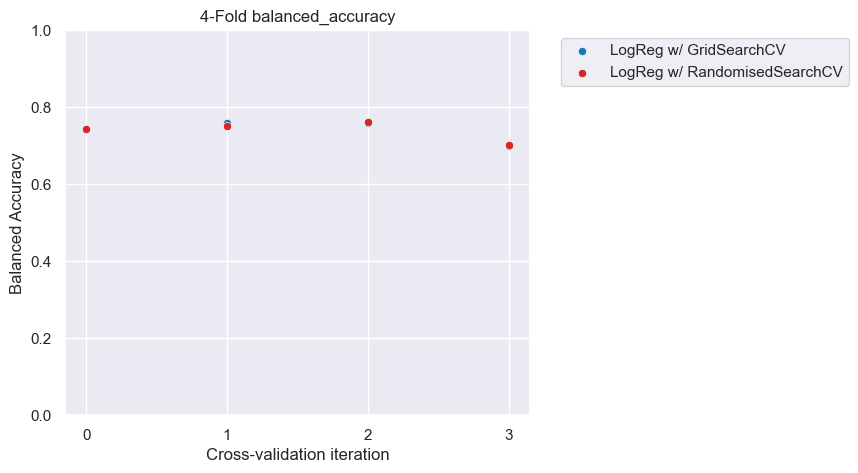

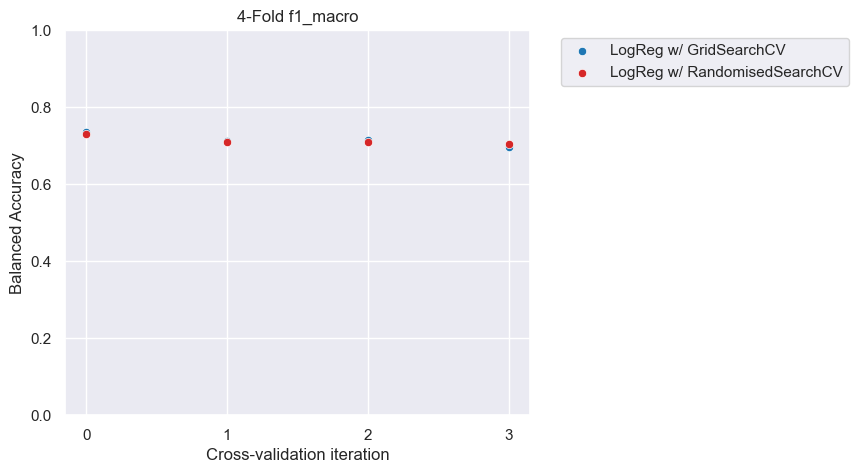

In [16]:
# plotting results from cv-folds for gridsearch and randomisedsearch logistic regression models
fold_results = (log_gridsearch_cv_score, log_randomsearch_cv_score)
label_names = ('LogReg w/ GridSearchCV', 'LogReg w/ RandomisedSearchCV')
colors=('blue', 'red')
psm_log.plot_fold_comparison(metric=psm_log.metrics[0], fold_results=fold_results, label_names=label_names, colors=colors)
psm_log.plot_fold_comparison(metric=psm_log.metrics[1], fold_results=fold_results, label_names=label_names, colors=colors)

**Which is the better linear model (tuned w/ GridSearchCV or RandomisedSearchCV)?**

* We have further proof that there is little separating the linear models tuned with GridSearchCV and RandomisedSearchCV. For all the folds, GridSearchCV performs similarly to RandomisedSearchCV for both the bal_accuracy and f1_macro metrics.

* Therefore, I will be proceeding with the RandomisedSearchCV tuned model since it is ~ 2.5x quicker.

### Tree Model - Decision Tree

#### Estimating generalisability of untuned Logistic Regression model

In [17]:
psm_tree = PlayerStatisticsModel(DecisionTreeClassifier(random_state=42), preprocessor, data, target, cv=4)
tree_cv_score_agg, tree_cv_score = psm_tree.cv_score(model_name='base_tree')
psm_tree.print_cv_results(tree_cv_score)

The mean cross-validation balanced_accuracy score is: 0.648 ± 0.640
The mean cross-validation f1_macro score is: 0.656 ± 0.646


In [18]:
# compare results
pd.concat([psm_log.results, psm_tree.results])

,balanced_accuracy_mean,f1_macro_mean,balanced_accuracy_std,f1_macro_std
base_log_reg,0.703900,0.712212,0.034306,0.022662
gridsearch_log_reg,0.740159,0.714791,0.024808,0.013772
randomsearch_log_reg,0.739129,0.713287,0.022296,0.009571
base_tree,0.640871,0.647558,0.010957,0.010351


* We observe the Tree has significantly worse performance in both balanced_accuracy and in f1_macro compared to all linear models. Perhaps the data is linearly separable, or the model is significantly overfitting. We need to make it simpler.

* There are a few options we can take. Mainly, specifying a `max_depth` that controls the complexity of the tree (i.e. underfitting/overfitting). Specifying `min_samples_split`, `max_leaf_nodes`, and `min_samples_leaf` enables an asymmetric tree.

#### Estimating generalisability of tuned Tree model varying Max Depth

In [19]:
param_grid = {"model__max_depth": np.arange(2, 16, 1)}

tree_gridsearch_cv_score_agg, tree_gridsearch_cv_score, tree_gridsearch_model = psm_tree.grid_search_cv_score(param_grid=param_grid, model_name='gridsearch_tree')

Fitting 5 folds for each of 14 candidates, totalling 70 fits
Fitting 5 folds for each of 14 candidates, totalling 70 fits
Fitting 5 folds for each of 14 candidates, totalling 70 fits
Fitting 5 folds for each of 14 candidates, totalling 70 fits
Fitting 5 folds for each of 14 candidates, totalling 70 fits
Fitting 5 folds for each of 14 candidates, totalling 70 fits
Fitting 5 folds for each of 14 candidates, totalling 70 fits
Fitting 5 folds for each of 14 candidates, totalling 70 fits


In [20]:
psm_tree.print_cv_results(tree_gridsearch_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.653 ± 0.029
The mean cross-validation f1_macro score is: 0.668 ± 0.025


In [21]:
# optimal max_depth
[value for param, value in tree_gridsearch_model.get_params().items() if param == 'model__max_depth']

[6]

* We observe there is a significant improvement in the model after making it simpler. However, it still underperforms relative to the linear models. Can we further improve performance by adjusting other hyperparameters to allow the tree to be asynmmetric?

#### Estimating generalisability of tuned Tree model with GridSearchCV

In [22]:
param_grid = {"model__max_depth": [9],
                "model__min_samples_split": [2, 5, 10],
                "model__min_samples_leaf": [1, 2, 4],
                "model__max_leaf_nodes": [None, 10, 20, 50]}

tree_all_gridsearch_cv_score_agg, tree_all_gridsearch_cv_score, tree_all_gridsearch_model = psm_tree.grid_search_cv_score(param_grid=param_grid, model_name='gridsearch_tree_all')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits


In [23]:
psm_tree.print_cv_results(tree_all_gridsearch_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.666 ± 0.029
The mean cross-validation f1_macro score is: 0.680 ± 0.031


In [24]:
# compare results
pd.concat([psm_log.results, psm_tree.results])

,balanced_accuracy_mean,f1_macro_mean,balanced_accuracy_std,f1_macro_std
base_log_reg,0.703900,0.712212,0.034306,0.022662
gridsearch_log_reg,0.740159,0.714791,0.024808,0.013772
randomsearch_log_reg,0.739129,0.713287,0.022296,0.009571
base_tree,0.640871,0.647558,0.010957,0.010351
gridsearch_tree,0.652721,0.667870,0.029310,0.025352
gridsearch_tree_all,0.665854,0.679741,0.028912,0.031168


* We observe a slight improvement in both `balanced_accuracy` and `f1_macro` after allowing for the creation of an asymmetric tree. However, the model still performs poorly compared to the linear models.

* We can further compare the folds between the best linear model (logistic regression with randomsearch) and best tree (asymmetric decision tree).

### Comparison of folds between best Logistic Regression & Decision Tree models

So far, is the best Logistic Regression Model (LogReg w/ RandomisedSearchCV) or best Tree Model (Asymmetric Tuned Tree) better?

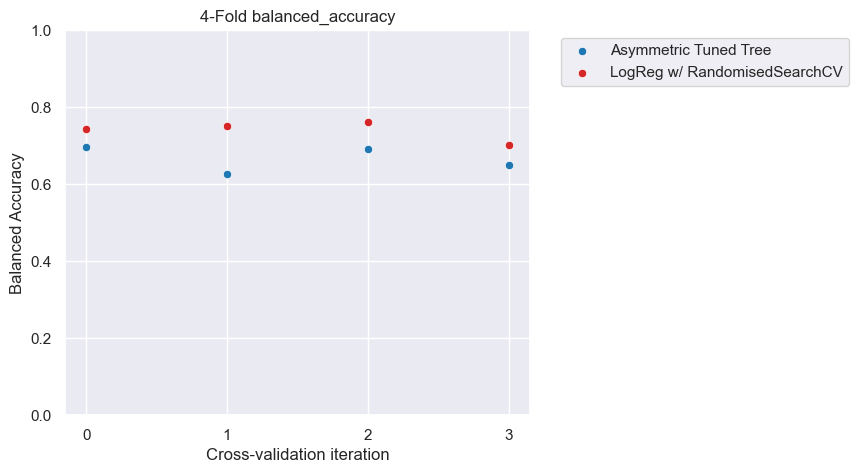

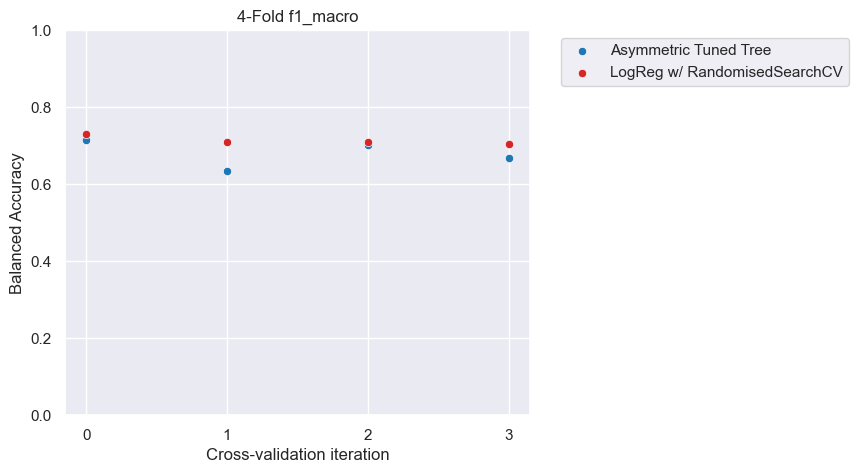

In [25]:
# plotting results from cv-folds for gridsearch and randomisedsearch logistic regression models
fold_results = (tree_all_gridsearch_cv_score, log_randomsearch_cv_score)
label_names = ('Asymmetric Tuned Tree', 'LogReg w/ RandomisedSearchCV')
colors=('blue', 'red')
psm_tree.plot_fold_comparison(metric=psm_tree.metrics[0], fold_results=fold_results, label_names=label_names, colors=colors)
psm_tree.plot_fold_comparison(metric=psm_tree.metrics[1], fold_results=fold_results, label_names=label_names, colors=colors)

* Emphatically, the best model is still logistic regression tuned with randomsearch as all 4 folds perform better in both the `balanced_accuracy` and `f1_macro` metrics.

### Ensemble Models - Random Forest

#### Estimating generalisability of untuned Random Forest

In [26]:
psm_rf = PlayerStatisticsModel(RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1), preprocessor, data, target, cv=4)
rf_cv_score_agg, rf_cv_score = psm_rf.cv_score(model_name='base_rf')
psm_rf.print_cv_results(rf_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.707 ± 0.046
The mean cross-validation f1_macro score is: 0.717 ± 0.035


* Even after hyperparameter tuning, the default Random Forest appeared to perform best. Furthermore, Random Forests are highly computational inefficient. Might Histogram-Based Gradient Boosting (more efficient on larger datasets) perform better?

In [27]:
pd.concat([psm_log.results, psm_tree.results, psm_rf.results])

,balanced_accuracy_mean,f1_macro_mean,balanced_accuracy_std,f1_macro_std
base_log_reg,0.703900,0.712212,0.034306,0.022662
gridsearch_log_reg,0.740159,0.714791,0.024808,0.013772
randomsearch_log_reg,0.739129,0.713287,0.022296,0.009571
base_tree,0.640871,0.647558,0.010957,0.010351
gridsearch_tree,0.652721,0.667870,0.029310,0.025352
gridsearch_tree_all,0.665854,0.679741,0.028912,0.031168
base_rf,0.707154,0.716650,0.046368,0.035318


### Ensemble Models - Histogram Gradient Boosting

In [28]:
psm_hbdc = PlayerStatisticsModel(HistGradientBoostingClassifier(max_iter=1000, early_stopping=True, random_state=42, class_weight='balanced'), preprocessor, data, target, cv=4)
hbdc_cv_score_agg, hbdc_cv_score = psm_hbdc.cv_score(model_name='base_hbdc')
psm_hbdc.print_cv_results(hbdc_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.722 ± 0.028
The mean cross-validation f1_macro score is: 0.714 ± 0.023


#### Estimating generalisability of tuned HBDC model with GridSearchCV

In [29]:
param_grid = {
    "model__max_depth": [3, 5, 8],
    "model__max_leaf_nodes": [15, 31],
    "model__learning_rate": [0.05, 0.01, 0.1, 0.2],
    "model__class_weight": ['balanced'],
    "model__early_stopping": [True]
}

hbdc_gridsearch_cv_score_agg, hbdc_gridsearch_cv_score, hbdc_gridsearch_model = psm_hbdc.grid_search_cv_score(param_grid=param_grid, model_name='gridsearch_hbdc')

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [30]:
psm_hbdc.print_cv_results(hbdc_gridsearch_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.735 ± 0.027
The mean cross-validation f1_macro score is: 0.719 ± 0.014


In [31]:
pd.concat([psm_log.results, psm_tree.results, psm_rf.results, psm_hbdc.results])

,balanced_accuracy_mean,f1_macro_mean,balanced_accuracy_std,f1_macro_std
base_log_reg,0.703900,0.712212,0.034306,0.022662
gridsearch_log_reg,0.740159,0.714791,0.024808,0.013772
randomsearch_log_reg,0.739129,0.713287,0.022296,0.009571
base_tree,0.640871,0.647558,0.010957,0.010351
gridsearch_tree,0.652721,0.667870,0.029310,0.025352
gridsearch_tree_all,0.665854,0.679741,0.028912,0.031168
base_rf,0.707154,0.716650,0.046368,0.035318
base_hbdc,0.721961,0.713665,0.027555,0.023174
gridsearch_hbdc,0.734967,0.718616,0.026959,0.013617


* While we observe a 2% increase in balanced accuracy and 1% increase in f1_macro via gridserch, the Histogram Gradient Boosting model still performs worse compared to the Random Search Logistic Regression model.

### SVM - Non-linear Kernel

In [32]:
psm_svm = PlayerStatisticsModel(SVC(random_state=42), preprocessor, data, target, cv=4)
svm_cv_score_agg, svm_cv_score = psm_svm.cv_score(model_name='linearsvc')
psm_svm.print_cv_results(svm_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.735 ± 0.044
The mean cross-validation f1_macro score is: 0.741 ± 0.030


In [33]:
param_grid = {
        "model__kernel": ["rbf"],
        "model__C": [0.1, 1, 10, 100],
        "model__gamma": ["scale", "auto", 0.01, 0.001],
        "model__class_weight": ["balanced"],
        "model__probability": [True]      # necessary for prediction probabilities in-app
    }

svm_gridsearch_cv_score_agg, svm_gridsearch_cv_score, svm_gridsearch_model = psm_svm.grid_search_cv_score(param_grid=param_grid, model_name='gridsearch_svm')

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 16 candidates, totalling 80 fits


In [34]:
psm_svm.print_cv_results(svm_gridsearch_cv_score_agg)

The mean cross-validation balanced_accuracy score is: 0.765 ± 0.015
The mean cross-validation f1_macro score is: 0.737 ± 0.014


In [35]:
psm_svm.get_best_tuned_params(svm_gridsearch_model, param_grid)

{'model__C': 10,
 'model__class_weight': 'balanced',
 'model__gamma': 'scale',
 'model__kernel': 'rbf',
 'model__probability': True}

### Gradient Boosting - XGBoost

#### Estimating generalisability of XGBoost model, tuned with Optuna

**Optuna** is an automatic hyperparameter optimisation framework. It offer advantages over simpler techniques like grid or random search, often by leveraging approaches such as Bayesian optimization.


In [36]:
warnings.filterwarnings(
    "ignore",
    category = UserWarning,
    module = "xgboost"
)

psm_xgb = PlayerStatisticsModel(
    model = None,  # placeholder
    preprocessor = preprocessor,
    data = data,
    target = target,
    cv = 5
)

xgb_cv_agg, xgb_cv_folds, xgb_best_model = psm_xgb.optuna_xgboost_cv_score(
    model_name = "optuna_xgb",
    n_trials = 30,
    inner_cv_splits = 3
)

[I 2026-01-25 13:47:55,269] A new study created in memory with name: xgb_optuna_optuna_xgb_outer1
[I 2026-01-25 13:48:07,166] Trial 0 finished with value: 0.7537747568739852 and parameters: {'learning_rate': 0.024030904436768495, 'max_depth': 9, 'subsample': 0.6219903614830804, 'colsample_bytree': 0.784057184918262, 'reg_lambda': 4.994037841292927e-07, 'reg_alpha': 0.00011307300191176599, 'gamma': 6.579138811394863e-07, 'min_child_weight': 6, 'n_estimators': 528}. Best is trial 0 with value: 0.7537747568739852.
[I 2026-01-25 13:48:09,039] Trial 1 finished with value: 0.763274932438116 and parameters: {'learning_rate': 0.04943328573821863, 'max_depth': 3, 'subsample': 0.8089960857422958, 'colsample_bytree': 0.6543578097066338, 'reg_lambda': 0.00018803910094031384, 'reg_alpha': 0.0019376790835319044, 'gamma': 3.33712483566968e-08, 'min_child_weight': 6, 'n_estimators': 268}. Best is trial 1 with value: 0.763274932438116.
[I 2026-01-25 13:48:14,242] Trial 2 finished with value: 0.73243525

In [37]:
psm_xgb.print_cv_results(xgb_cv_agg)

The mean cross-validation balanced_accuracy score is: 0.774 ± 0.009
The mean cross-validation f1_macro score is: 0.754 ± 0.010


### Estimating generalisability of LightGBM model, tuned with Optuna

In [38]:
psm_lgb = PlayerStatisticsModel(
    model=None,  # placeholder
    preprocessor=preprocessor,
    data=data,
    target=target,
    cv=5
)

lgb_cv_agg, lgb_cv_folds, lgb_best_model = psm_lgb.optuna_lightgbm_cv_score(
    model_name = "optuna_lgbm",
    n_trials = 30,
    inner_cv_splits = 3
)

[I 2026-01-25 13:58:25,615] A new study created in memory with name: lgbm_optuna_optuna_lgbm_outer1
[I 2026-01-25 13:58:37,193] Trial 0 finished with value: 0.7378330918534756 and parameters: {'learning_rate': 0.1429951971073717, 'num_leaves': 37, 'max_depth': 10, 'min_child_samples': 8, 'subsample': 0.6527613247378627, 'colsample_bytree': 0.610346482149275, 'reg_alpha': 0.030808537537933577, 'reg_lambda': 0.05586105275560546, 'n_estimators': 759}. Best is trial 0 with value: 0.7378330918534756.
[I 2026-01-25 13:58:39,881] Trial 1 finished with value: 0.7626333099791437 and parameters: {'learning_rate': 0.023147611998395812, 'num_leaves': 253, 'max_depth': 3, 'min_child_samples': 28, 'subsample': 0.6386908424343332, 'colsample_bytree': 0.6100308796598505, 'reg_alpha': 0.05147457680734318, 'reg_lambda': 0.8914367033640449, 'n_estimators': 427}. Best is trial 1 with value: 0.7626333099791437.
[I 2026-01-25 13:58:44,410] Trial 2 finished with value: 0.7510471258115238 and parameters: {'le

In [39]:
psm_lgb.print_cv_results(lgb_cv_agg)

The mean cross-validation balanced_accuracy score is: 0.770 ± 0.009
The mean cross-validation f1_macro score is: 0.750 ± 0.014


### Final model results comparison

In [40]:
pd.concat([psm_log.results, psm_tree.results, psm_rf.results, psm_hbdc.results, psm_svm.results, psm_xgb.results, psm_lgb.results]).sort_values(by=['balanced_accuracy_mean', 'f1_macro_mean'], ascending=False)

,balanced_accuracy_mean,f1_macro_mean,balanced_accuracy_std,f1_macro_std
optuna_xgb,0.773899,0.754054,0.008572,0.010431
optuna_lgbm,0.770183,0.749587,0.009125,0.014224
gridsearch_svm,0.764991,0.736670,0.014688,0.014449
gridsearch_log_reg,0.740159,0.714791,0.024808,0.013772
randomsearch_log_reg,0.739129,0.713287,0.022296,0.009571
gridsearch_hbdc,0.734967,0.718616,0.026959,0.013617
linearsvc,0.734719,0.740607,0.043883,0.030214
base_hbdc,0.721961,0.713665,0.027555,0.023174
base_rf,0.707154,0.716650,0.046368,0.035318
base_log_reg,0.703900,0.712212,0.034306,0.022662


Since the **Optuna LGBM model peformed best** on both the balanced accuracy and f1_macro metrics, we will seralise this model to use in the app.

## (5) Fit & Evaluate Best Performing Model

Let's validate the performance of the best performing model (XGBoost). We will fit the an XGBoost model on the training data with the best performing hyperparameters from the Optuna bayesian optimisation. The model will be evaluated on the test set.  

While the nested CV gives us our final reported metrics, this evaluatory model should validate the generalisability of the best LGBM model when exposed to new and unseen data.

In [41]:
# 1. Compute class weights on train
classes_train = np.unique(psm_xgb.y_train)
class_weights_train = compute_class_weight(class_weight="balanced", classes=classes_train, y=psm_xgb.y_train)
class_weight_dict_train = dict(zip(classes_train, class_weights_train))

if hasattr(psm_xgb.y_train, "map"):
    sample_weight_train = psm_xgb.y_train.map(class_weight_dict_train).to_numpy()
else:
    sample_weight_train = np.array([class_weight_dict_train[c] for c in psm_xgb.y_train])

# 2. Fit tuned LightGBM on train set only, accounting for class weights to handle imbalance
with psm_xgb._suppress_warnings_and_output():
    xgb_best_model.fit(psm_xgb.X_train, psm_xgb.y_train, model__sample_weight = sample_weight_train)

# 3. Evaluate on test
y_test_pred = xgb_best_model.predict(psm_xgb.X_test)

ba_test = balanced_accuracy_score(psm_xgb.y_test, y_test_pred)
f1_test = f1_score(psm_xgb.y_test, y_test_pred, average="macro")

print(f"LightGBM Test Balanced Accuracy: {ba_test:.3f}")
print(f"LightGBM Test F1 Macro:          {f1_test:.3f}\n")

print("Classification report (test set):")
print(classification_report(psm_xgb.y_test, y_test_pred))

print("Confusion matrix (test set):")
print(confusion_matrix(psm_xgb.y_test, y_test_pred))


LightGBM Test Balanced Accuracy: 0.787
LightGBM Test F1 Macro:          0.766

Classification report (test set):
              precision    recall  f1-score   support

           0       0.68      0.85      0.75       140
           1       0.74      0.67      0.70       369
           2       0.84      0.84      0.84       445

    accuracy                           0.78       954
   macro avg       0.75      0.79      0.77       954
weighted avg       0.78      0.78      0.78       954

Confusion matrix (test set):
[[119  21   0]
 [ 53 246  70]
 [  4  65 376]]


* The main metrics are extremely similar between the nested cv (`bal_accuracy` = 0.774, `f1_macro` = 0.754) and evaluatory model (`bal_accuracy` = 0.787, `f1_macro` = 0.766). This suggests the performance of best XGBoost model is likely to generalise to new and unseen data.  

* The class mapping is as follows: Class 0: Center, Class 1: Forward, Class 2: Guard. 

* While the model is able to accurately classify guards, it struggles with centers.

* As expected, there are very few cases where Guards are misclassified as Centers and vice-versa (only 4). Most errors occur along the natural positional boundaries — Guards→Forwards and Forwards→Centers. While not perfect, these are far more acceptable: they reflect players who could reasonably fit into either mould, whereas Guard→Center errors would indicate the model is fundamentally misunderstanding the player's archetype.
  

## (6) Retrain Best Performing Model on Entire Dataset

Finally, I will retrain the model on the full dataset (training & validation sets) to help the model learn from as much data as possible.

In [51]:
# 1. Compute class weights on entire dataset
classes_full = np.unique(target)
class_weights_full = compute_class_weight(class_weight="balanced", classes=classes_full, y=target)
class_weight_dict_full = dict(zip(classes_full, class_weights_full))

if hasattr(target, "map"):
    sample_weight_full = target.map(class_weight_dict_full).to_numpy()
else:
    sample_weight_full = np.array([class_weight_dict_full[c] for c in target])

# 2. Fit tuned XGBoost, accounting for class weights to handle imbalance
# n.b. running .fit() for a second time will overwrite all previously fitted coefficients, weights, etc
with psm_xgb._suppress_warnings_and_output():
    best_model = xgb_best_model.fit(data, target, model__sample_weight = sample_weight_full)

In [ ]:
# Export model
# pickle.dump(best_model, open(os.path.join("models", "stats_model.sav"), "wb"))
# pickle.dump(le, open(os.path.join("models", "stats_encoder.sav"), "wb"))

# (7) Test on Dummy Inputs

In [55]:
data.head()

,PTS,AST,REB,STL,BLK,TOV,AST_TO,STOCKS,FIC
0,2.50,0.38,1.12,0.04,0.08,0.08,4.750000,0.12,4.04
1,6.40,0.89,2.55,0.36,0.26,0.38,2.342105,0.62,10.08
2,9.01,1.04,3.49,0.51,0.32,0.41,2.536585,0.83,13.96
3,7.82,1.04,2.21,0.28,0.10,0.60,1.733333,0.38,10.85
4,7.38,0.88,4.05,0.41,0.86,0.83,1.060241,1.27,12.75


In [65]:
def load_model(model):
    return pickle.load(open(model, 'rb'))

stats_predictor = load_model(os.path.join("models", "stats_model.sav"))
stats_le = load_model(os.path.join("models", "stats_encoder.sav"))

# Example inputs
pts, ast, reb, stl, blk, tov = 20, 2, 10, 1, 1, 2
ast_to, stocks, fic = round(ast/tov, 2), round(stl+blk, 2), round(pts+reb+ast+stl+blk-tov, 2)
input_features = pd.DataFrame([[pts, ast, reb, stl, blk, tov, ast_to, stocks, fic]], 
                            columns=['PTS', 'AST', 'REB', 'STL', 'BLK', 'TOV', 'AST_TO', 'STOCKS', 'FIC'])
stats_predictor.predict(input_features)
predicted_pos = stats_le.inverse_transform(stats_predictor.predict(input_features))[0][0]   # obtain prediction using models
print(predicted_pos)

# The pipeline will handle the scaling internally
predicted_pos = stats_le.inverse_transform(stats_predictor.predict(input_features))[0]

predicted_proba = stats_predictor.predict_proba(input_features).flatten()
print(predicted_proba)
all_positions = stats_le.inverse_transform([0, 1, 2])
{pos: prob for pos, prob in zip(all_positions, predicted_proba)}

C
[0.8836353  0.11046553 0.00589916]


{'C': 0.8836353, 'F': 0.11046553, 'G': 0.00589916}